# Proyek Klasifikasi Gambar: Intel Image Classification
- **Nama:** Nazwa Nabila
- **Email:** nzwnabila@gmail.com
- **ID Dicoding:** CACC319D6X0515

## Import Library

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import shutil
import random
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')

TensorFlow version: 2.20.0
Keras version: 3.13.2


## Data Preparation

### Data Loading

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nazwaanbl","key":"cf1267267a2196f2bc859a96645c8d28"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [5]:
BASE_DIR = '/content/intel-image-classification'
TRAIN_DIR = '/content/seg_train/seg_train'
TEST_DIR  = '/content/seg_test/seg_test'

# Direktori output untuk split dataset
DATASET_DIR = 'dataset'
TRAIN_SPLIT  = os.path.join(DATASET_DIR, 'train')
VAL_SPLIT    = os.path.join(DATASET_DIR, 'validation')
TEST_SPLIT   = os.path.join(DATASET_DIR, 'test')

# Kelas
CLASSES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# Hyperparameter
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 30

print('Konfigurasi:')
print(f'  Kelas       : {CLASSES}')
print(f'  Ukuran Gambar: {IMG_SIZE}')
print(f'  Batch Size  : {BATCH_SIZE}')
print(f'  Max Epochs  : {EPOCHS}')

Konfigurasi:
  Kelas       : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
  Ukuran Gambar: (224, 224)
  Batch Size  : 32
  Max Epochs  : 30


### Exploratory Data Analysis

In [6]:
def count_images(base_path):
    """Hitung jumlah gambar per kelas."""
    counts = {}
    total  = 0
    for cls in CLASSES:
        cls_path = os.path.join(base_path, cls)
        if os.path.exists(cls_path):
            n = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            counts[cls] = n
            total += n
        else:
            counts[cls] = 0
    return counts, total

train_counts, train_total = count_images(TRAIN_DIR)
test_counts,  test_total  = count_images(TEST_DIR)

print('=== Distribusi Dataset ===' )
print(f'{"Kelas":<12} {"Train":>8} {"Test":>8}')
print('-' * 30)
for cls in CLASSES:
    print(f'{cls:<12} {train_counts[cls]:>8} {test_counts[cls]:>8}')
print('-' * 30)
print(f'{"TOTAL":<12} {train_total:>8} {test_total:>8}')
print(f'\nTotal keseluruhan: {train_total + test_total} gambar')

=== Distribusi Dataset ===
Kelas           Train     Test
------------------------------
buildings        2191      437
forest           2271      474
glacier          2404      553
mountain         2512      525
sea              2274      510
street           2382      501
------------------------------
TOTAL           14034     3000

Total keseluruhan: 17034 gambar


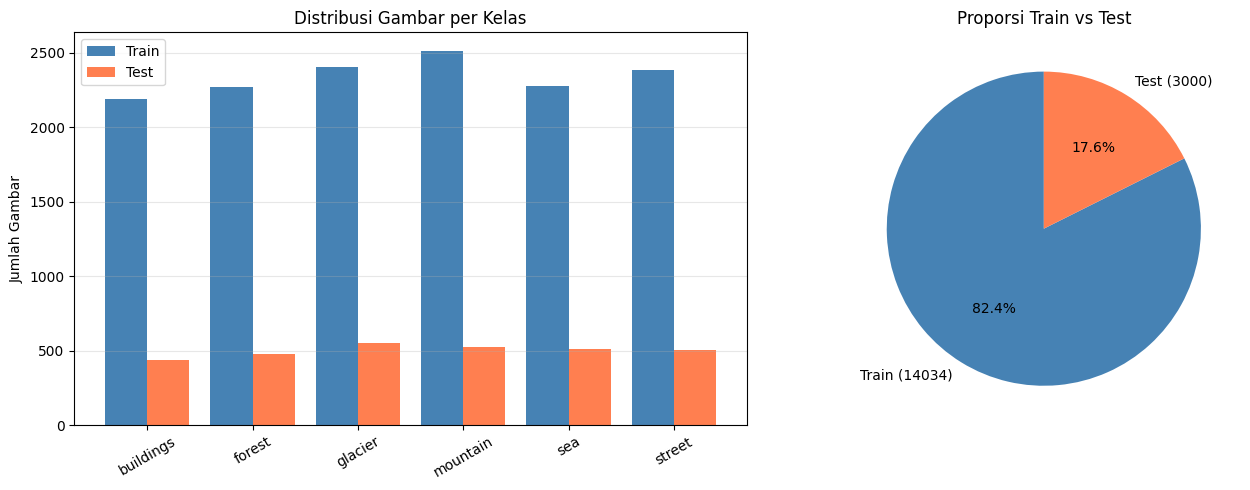

In [7]:
# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
x = np.arange(len(CLASSES))
axes[0].bar(x - 0.2, [train_counts[c] for c in CLASSES], 0.4, label='Train', color='steelblue')
axes[0].bar(x + 0.2, [test_counts[c]  for c in CLASSES], 0.4, label='Test',  color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASSES, rotation=30)
axes[0].set_title('Distribusi Gambar per Kelas')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Pie chart total
axes[1].pie([train_total, test_total],
            labels=[f'Train ({train_total})', f'Test ({test_total})'],
            autopct='%1.1f%%',
            colors=['steelblue', 'coral'],
            startangle=90)
axes[1].set_title('Proporsi Train vs Test')

plt.tight_layout()
plt.savefig('distribution.png', dpi=100, bbox_inches='tight')
plt.show()

=== Cek Resolusi Gambar Asli (Tidak Seragam) ===
buildings   : [(150, 150), (150, 150), (150, 150), (150, 150), (150, 150)]
forest      : [(150, 150), (150, 150), (150, 150), (150, 150), (150, 150)]
glacier     : [(150, 150), (150, 150), (150, 150), (150, 150), (150, 150)]
mountain    : [(150, 150), (150, 150), (150, 150), (150, 150), (150, 150)]
sea         : [(150, 150), (150, 150), (150, 150), (150, 150), (150, 150)]
street      : [(150, 150), (150, 150), (150, 150), (150, 150), (150, 150)]


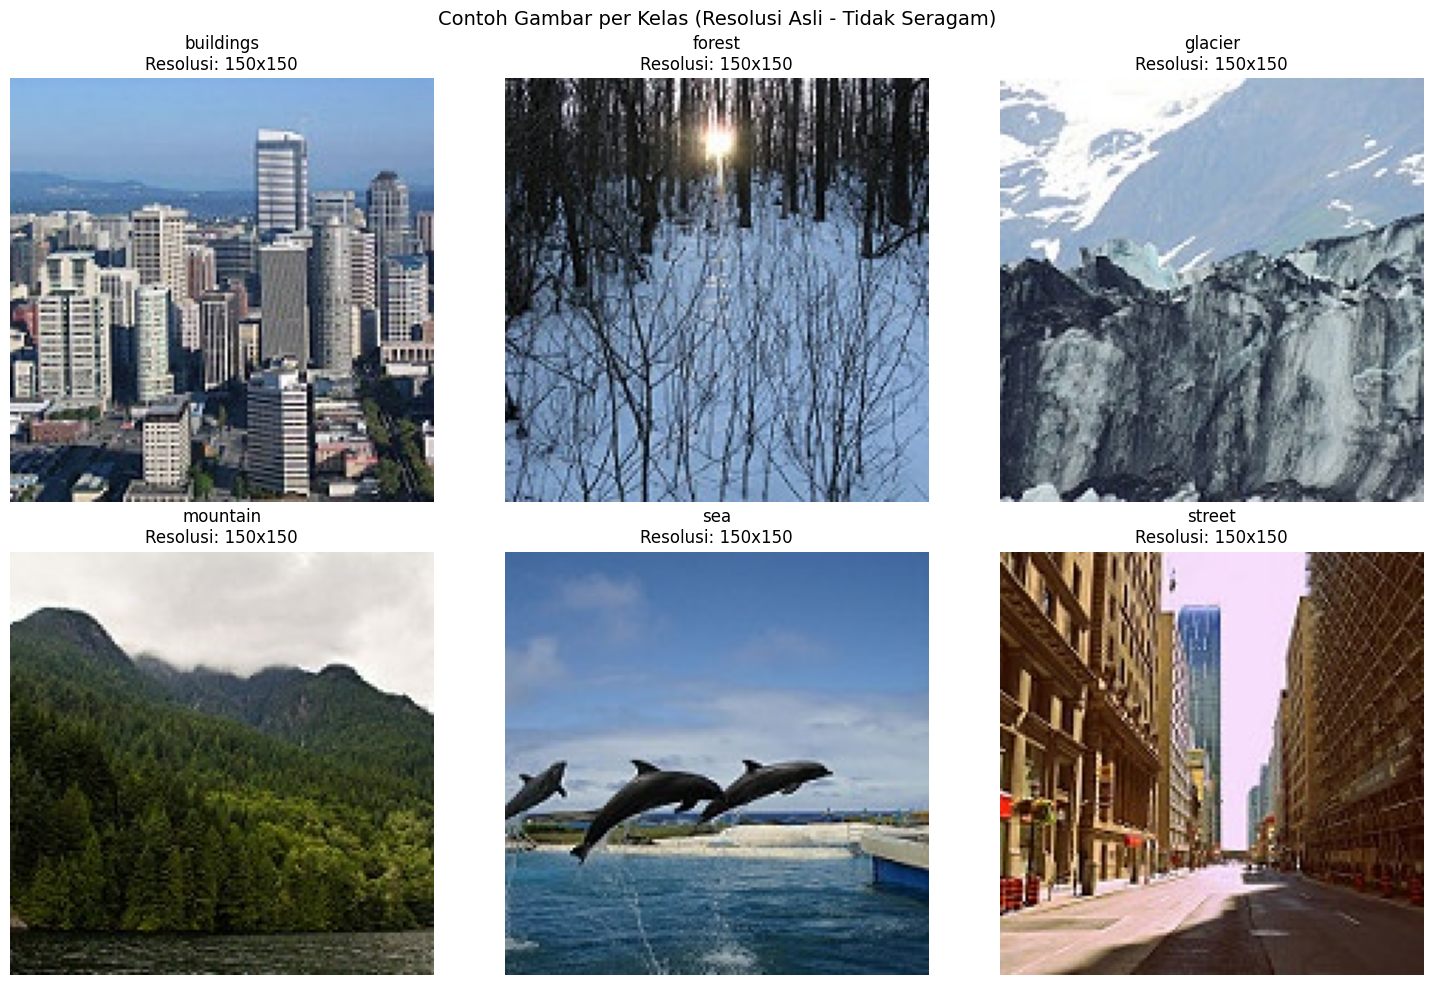

In [8]:
# Tampilkan contoh gambar dari setiap kelas + cek resolusi (tidak seragam)
print('=== Cek Resolusi Gambar Asli (Tidak Seragam) ===')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = os.listdir(cls_path)[:5]

    # Cek beberapa resolusi
    sizes = []
    for img_name in images:
        img_path = os.path.join(cls_path, img_name)
        with Image.open(img_path) as img:
            sizes.append(img.size)

    print(f'{cls:12}: {sizes}')

    # Tampilkan 1 gambar per kelas
    sample_img = mpimg.imread(os.path.join(cls_path, images[0]))
    ax = axes[idx // 3][idx % 3]
    ax.imshow(sample_img)
    ax.set_title(f'{cls}\nResolusi: {sample_img.shape[1]}x{sample_img.shape[0]}')
    ax.axis('off')

plt.suptitle('Contoh Gambar per Kelas (Resolusi Asli - Tidak Seragam)', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## Data Preprocessing

### Split Dataset

Pembagian: **70% Train | 20% Validation | 10% Test** (dari data train asli).  
Data test asli dari Kaggle digunakan sebagai test set tambahan.

In [9]:
def split_dataset(src_train, src_test, dest_train, dest_val, dest_test,
                  train_ratio=0.70, val_ratio=0.20):
    """Bagi dataset ke train/val/test dan salin ke folder baru."""

    # Hapus folder lama jika ada
    for d in [dest_train, dest_val, dest_test]:
        if os.path.exists(d):
            shutil.rmtree(d)

    random.seed(42)
    summary = {}

    for cls in CLASSES:
        src_cls = os.path.join(src_train, cls)
        files   = [f for f in os.listdir(src_cls)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(files)

        n       = len(files)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)

        splits = {
            dest_train : files[:n_train],
            dest_val   : files[n_train:n_train + n_val],
            dest_test  : files[n_train + n_val:],
        }

        summary[cls] = {'train': n_train, 'val': n_val, 'test': n - n_train - n_val}

        for dest, file_list in splits.items():
            dest_cls = os.path.join(dest, cls)
            os.makedirs(dest_cls, exist_ok=True)
            for fname in file_list:
                shutil.copy2(os.path.join(src_cls, fname),
                             os.path.join(dest_cls, fname))

    return summary

summary = split_dataset(TRAIN_DIR, TEST_DIR, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT)

print('\n=== Hasil Pembagian Dataset ===')
print(f'{"Kelas":<12} {"Train":>8} {"Val":>8} {"Test":>8}')
print('-' * 40)
total_train = total_val = total_test = 0
for cls in CLASSES:
    t, v, ts = summary[cls]['train'], summary[cls]['val'], summary[cls]['test']
    print(f'{cls:<12} {t:>8} {v:>8} {ts:>8}')
    total_train += t; total_val += v; total_test += ts
print('-' * 40)
print(f'{"TOTAL":<12} {total_train:>8} {total_val:>8} {total_test:>8}')
print(f'\nGrand Total: {total_train + total_val + total_test} gambar')


=== Hasil Pembagian Dataset ===
Kelas           Train      Val     Test
----------------------------------------
buildings        1533      438      220
forest           1589      454      228
glacier          1682      480      242
mountain         1758      502      252
sea              1591      454      229
street           1667      476      239
----------------------------------------
TOTAL            9820     2804     1410

Grand Total: 14034 gambar


## Data Augmentation dan Generator

In [10]:
# ImageDataGenerator dengan augmentasi untuk training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validasi dan test: hanya rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_SPLIT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_SPLIT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_SPLIT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'\nIndeks kelas: {train_generator.class_indices}')
print(f'Steps per epoch (train) : {len(train_generator)}')
print(f'Steps per epoch (val)   : {len(val_generator)}')
print(f'Steps per epoch (test)  : {len(test_generator)}')

Found 9820 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 1410 images belonging to 6 classes.

Indeks kelas: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Steps per epoch (train) : 307
Steps per epoch (val)   : 88
Steps per epoch (test)  : 45


## Arsitektur Model

In [11]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    # Conv2D dan Pooling
    base_model,

    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2d_explicit'),
    layers.MaxPooling2D((2, 2), name='maxpool_explicit'),

    # Head klasifikasi
    layers.GlobalAveragePooling2D(name='gap'),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(CLASSES), activation='softmax')
], name='MobileNetV2_With_Conv2D')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_With_Conv2D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_explicit (Conv2D)        │ (None, 7, 7, 128)      │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_explicit (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,799,878 (14.50 MB)

 Trainable params: 1,541,638 (5.88 MB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [12]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Total parameter: {model.count_params():,}')

Total parameter: 3,799,878


## Callback

In [13]:
os.makedirs('models', exist_ok=True)

# Callback 1: ModelCheckpoint – simpan model terbaik
checkpoint_cb = ModelCheckpoint(
    filepath='models/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Callback 2: EarlyStopping – hentikan jika tidak ada kemajuan
early_stop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Callback 3: ReduceLROnPlateau – kurangi learning rate jika stagnan
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Callback 4: Custom callback – hentikan jika akurasi sudah cukup tinggi
class AccuracyThresholdCallback(keras.callbacks.Callback):
    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy', 0)
        train_acc = logs.get('accuracy', 0)
        if val_acc >= self.threshold and train_acc >= self.threshold:
            print(f'\n Epoch {epoch+1}: Akurasi target {self.threshold*100}% tercapai!')
            print(f'   Train: {train_acc:.4f} | Val: {val_acc:.4f}')
            self.model.stop_training = True

accuracy_threshold_cb = AccuracyThresholdCallback(threshold=0.95)

callbacks = [checkpoint_cb, early_stop_cb, reduce_lr_cb, accuracy_threshold_cb]
print('Callbacks berhasil dibuat')

Callbacks berhasil dibuat


## Training Model

In [14]:
print('Mulai training model...')
print('=' * 60)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining selesai!')

Mulai training model...
Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.7473 - loss: 0.6816
Epoch 1: val_accuracy improved from None to 0.89479, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 176s 500ms/step - accuracy: 0.8106 - loss: 0.5148 - val_accuracy: 0.8948 - val_loss: 0.3188 - learning_rate: 0.0010
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.8677 - loss: 0.3783
Epoch 2: val_accuracy improved from 0.89479 to 0.90549, saving model to models/best_model.keras

Epoch 2: finished saving model to models/best_model.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 123s 400ms/step - accuracy: 0.8629 - loss: 0.3804 - val_accuracy: 0.9055 - val_loss: 0.2797 - learning_rate: 0.0010
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.8744 - loss: 0.3552
Epoch 3: val_accuracy improved from 0.90549 to 0.91191, saving model to models/best_model.keras

Epoch 3: finished 

## Fine-tuning

In [15]:
# Unfreeze base model
base_model.trainable = True

# Freeze layer awal, unfreeze hanya 50 layer terakhir
for layer in base_model.layers[:-100]:
    layer.trainable = False

# Compile ulang dengan learning rate sangat kecil
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Trainable layers: {len([l for l in model.layers if l.trainable])}')

# Training lanjut (fine-tuning)
history_fine = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Trainable layers: 10
Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.7711 - loss: 0.7030
Epoch 1: val_accuracy did not improve from 0.91940
307/307 ━━━━━━━━━━━━━━━━━━━━ 188s 492ms/step - accuracy: 0.7968 - loss: 0.6016 - val_accuracy: 0.9044 - val_loss: 0.3137 - learning_rate: 1.0000e-05
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8355 - loss: 0.4597
Epoch 2: val_accuracy did not improve from 0.91940
307/307 ━━━━━━━━━━━━━━━━━━━━ 126s 410ms/step - accuracy: 0.8432 - loss: 0.4375 - val_accuracy: 0.8994 - val_loss: 0.3298 - learning_rate: 1.0000e-05
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.8633 - loss: 0.3968
Epoch 3: val_accuracy did not improve from 0.91940

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
307/307 ━━━━━━━━━━━━━━━━━━━━ 126s 410ms/step - accuracy: 0.8673 - loss: 0.3777 - val_accuracy: 0.9098 - val_loss: 0.2908 - learning_rate: 1.0000e-05
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━

## Visualisasi Akurasi dan Loss

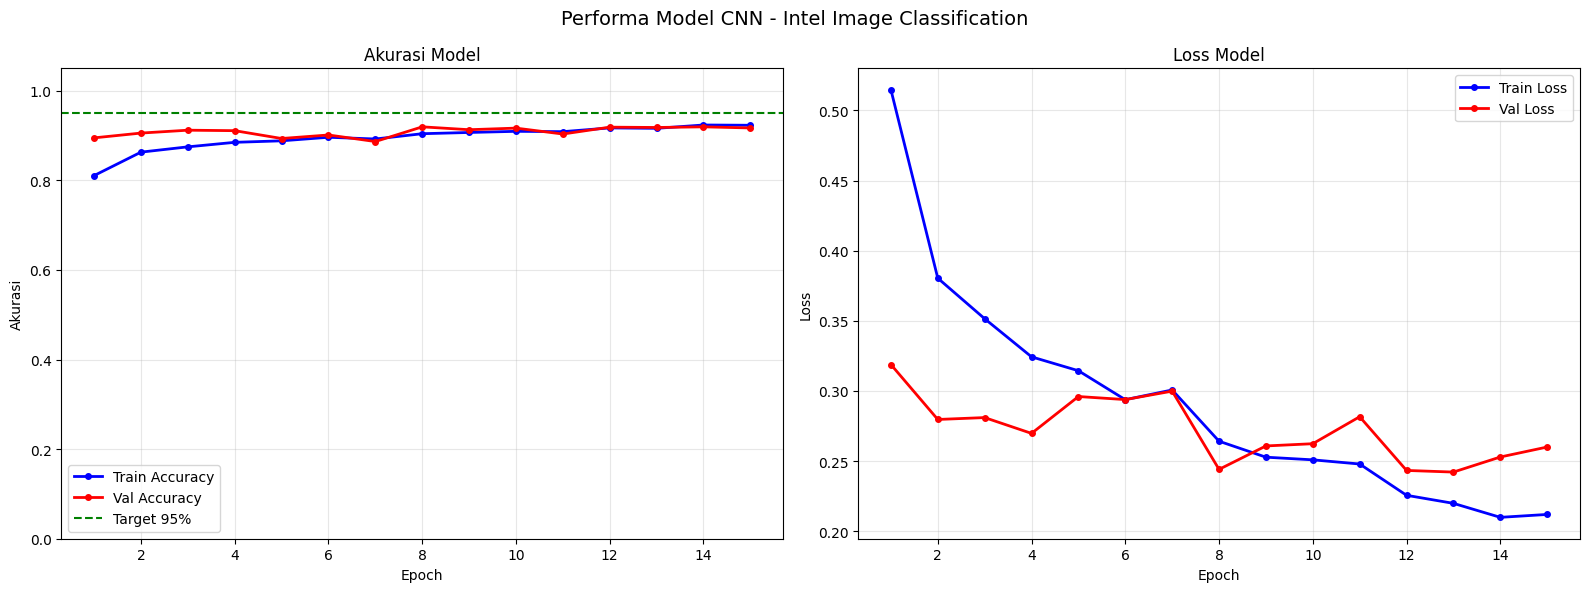


Akurasi Train Akhir : 0.9229 (92.29%)
Akurasi Val Akhir   : 0.9169 (91.69%)
Loss Train Akhir    : 0.2119
Loss Val Akhir      : 0.2600


In [16]:
acc       = history.history['accuracy']
val_acc   = history.history['val_accuracy']
loss      = history.history['loss']
val_loss  = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performa Model CNN - Intel Image Classification', fontsize=14)

# Plot Akurasi
axes[0].plot(epochs_range, acc,     'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[0].plot(epochs_range, val_acc, 'r-o', label='Val Accuracy',   linewidth=2, markersize=4)
axes[0].axhline(y=0.95, color='green', linestyle='--', label='Target 95%')
axes[0].set_title('Akurasi Model')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Plot Loss
axes[1].plot(epochs_range, loss,     'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[1].plot(epochs_range, val_loss, 'r-o', label='Val Loss',   linewidth=2, markersize=4)
axes[1].set_title('Loss Model')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nAkurasi Train Akhir : {acc[-1]:.4f} ({acc[-1]*100:.2f}%)')
print(f'Akurasi Val Akhir   : {val_acc[-1]:.4f} ({val_acc[-1]*100:.2f}%)')
print(f'Loss Train Akhir    : {loss[-1]:.4f}')
print(f'Loss Val Akhir      : {val_loss[-1]:.4f}')

## Evaluasi Model pada Test Set

In [17]:
# Load model terbaik
best_model = keras.models.load_model('models/best_model.keras')

# Evaluasi
print('Evaluasi pada Test Set...')
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)

print('\n' + '=' * 50)
print(f'  Test Loss    : {test_loss:.4f}')
print(f'  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print('=' * 50)

if test_acc >= 0.95:
    print('Akurasi test >= 95%')
elif test_acc >= 0.85:
    print('Akurasi test >= 85%')
else:
    print('Akurasi test < 85%')

Evaluasi pada Test Set...
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 297ms/step - accuracy: 0.9128 - loss: 0.2321

  Test Loss    : 0.2321
  Test Accuracy: 0.9128 (91.28%)
Akurasi test >= 85%


45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 157ms/step

=== Classification Report ===
              precision    recall  f1-score   support

   buildings       0.91      0.92      0.92       220
      forest       0.98      0.98      0.98       228
     glacier       0.86      0.84      0.85       242
    mountain       0.86      0.86      0.86       252
         sea       0.94      0.96      0.95       229
      street       0.92      0.93      0.93       239

    accuracy                           0.91      1410
   macro avg       0.91      0.91      0.91      1410
weighted avg       0.91      0.91      0.91      1410



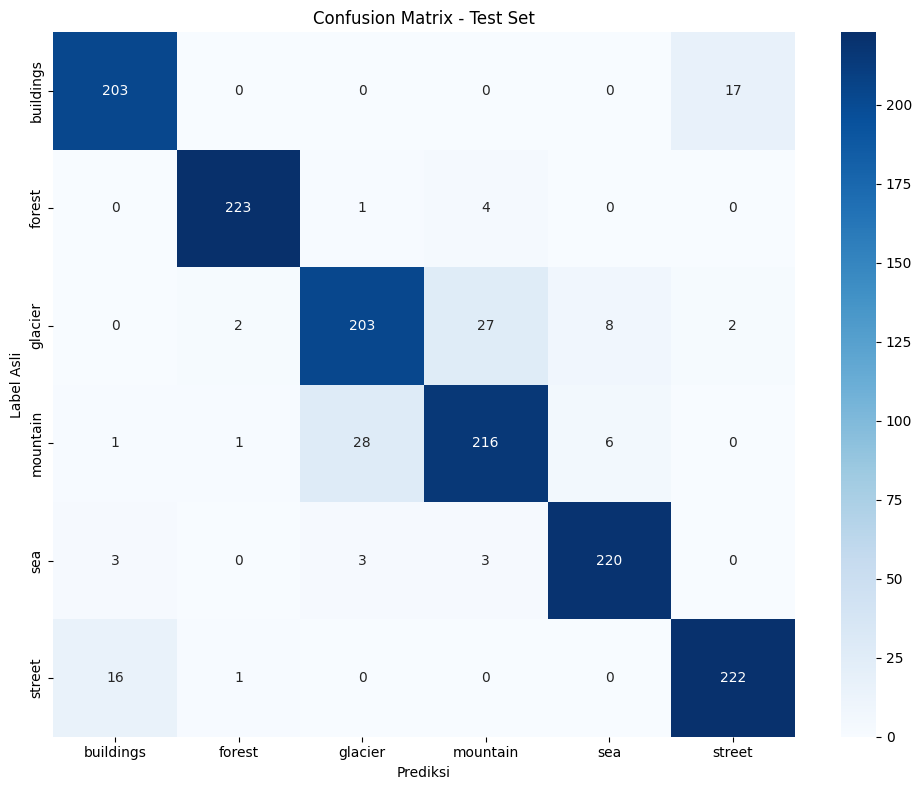

In [18]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Classification report
print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Label Asli')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## Konversi Model

### SavedModel (TensorFlow)

In [19]:
saved_model_path = 'saved_model'
best_model.export(saved_model_path)

print(f'SavedModel disimpan ke: {saved_model_path}')
print(f'Isi folder:')
for root, dirs, files in os.walk(saved_model_path):
    level = root.replace(saved_model_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for f in files:
        fpath = os.path.join(root, f)
        size  = os.path.getsize(fpath) / (1024 * 1024)
        print(f'{subindent}{f} ({size:.2f} MB)')

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  138829317760848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317762960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317762768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317760656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317763536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317763920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317764112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317763152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317763728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317764688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317762384: T

### TF-Lite

In [21]:
# Konversi ke TF-Lite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Quantization
tflite_model = converter.convert()

tflite_path = 'tflite/model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f' TF-Lite model disimpan ke: {tflite_path}')
print(f'   Ukuran file: {size_mb:.2f} MB')

Saved artifact at '/tmp/tmp6g0colri'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  138829317760848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317762960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317762768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317760656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317763536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317763920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317764112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317763152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317763728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138829317764688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1388293177623

In [22]:
# Buat label.txt
os.makedirs('tflite', exist_ok=True)

with open('tflite/label.txt', 'w') as f:
    for cls in CLASSES:
        f.write(cls + '\n')

print('Isi label.txt:')
with open('tflite/label.txt') as f:
    print(f.read())

Isi label.txt:
buildings
forest
glacier
mountain
sea
street



### TensorFlow.js (TFJS)

In [24]:
import subprocess

tfjs_path = 'tfjs_model'
os.makedirs(tfjs_path, exist_ok=True)

# Simpan dulu sebagai .keras
keras_path = 'tfjs_model/model_for_tfjs.keras'
best_model.save(keras_path)

# Konversi ke TFJS
result = subprocess.run(
    ['tensorflowjs_converter',
     '--input_format=keras',
     keras_path,
     tfjs_path],
    capture_output=True, text=True
)

if result.returncode == 0:
    print(f' TFJS model disimpan ke: {tfjs_path}')
    print('Isi folder:')
    for f in os.listdir(tfjs_path):
        fpath = os.path.join(tfjs_path, f)
        size  = os.path.getsize(fpath) / (1024 * 1024)
        print(f'  {f} ({size:.2f} MB)')
else:
    print('Error:', result.stderr)
    # Alternatif: gunakan SavedModel sebagai input
    result2 = subprocess.run(
        ['tensorflowjs_converter',
         '--input_format=tf_saved_model',
         saved_model_path,
         tfjs_path],
        capture_output=True, text=True
    )
    if result2.returncode == 0:
        print(f' TFJS model disimpan ke: {tfjs_path} (dari SavedModel)')
    else:
        print('Error alternatif:', result2.stderr)

Error: 2026-05-03 17:43:20.087797: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777830200.193056   21679 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777830200.227609   21679 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777830200.257033   21679 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777830200.257068   21679 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777830200.257071   21679 computation_placer.cc:177] computation pla

In [25]:
print(os.listdir('tfjs_model'))

['group1-shard3of4.bin', 'group1-shard1of4.bin', 'model_for_tfjs.keras', 'group1-shard4of4.bin', 'group1-shard2of4.bin', 'model.json']


## Inference / Prediksi dengan Model

### Inference dengan SavedModel

=== Hasil Prediksi (SavedModel) ===
No   Label Asli   Prediksi       Confidence Status
-------------------------------------------------------
1    buildings    buildings        100.00% Benar
2    forest       forest            99.77% Benar
3    glacier      glacier           84.96% Benar
4    mountain     mountain          96.08% Benar
5    sea          sea               97.81% Benar
6    street       street            86.86% Benar


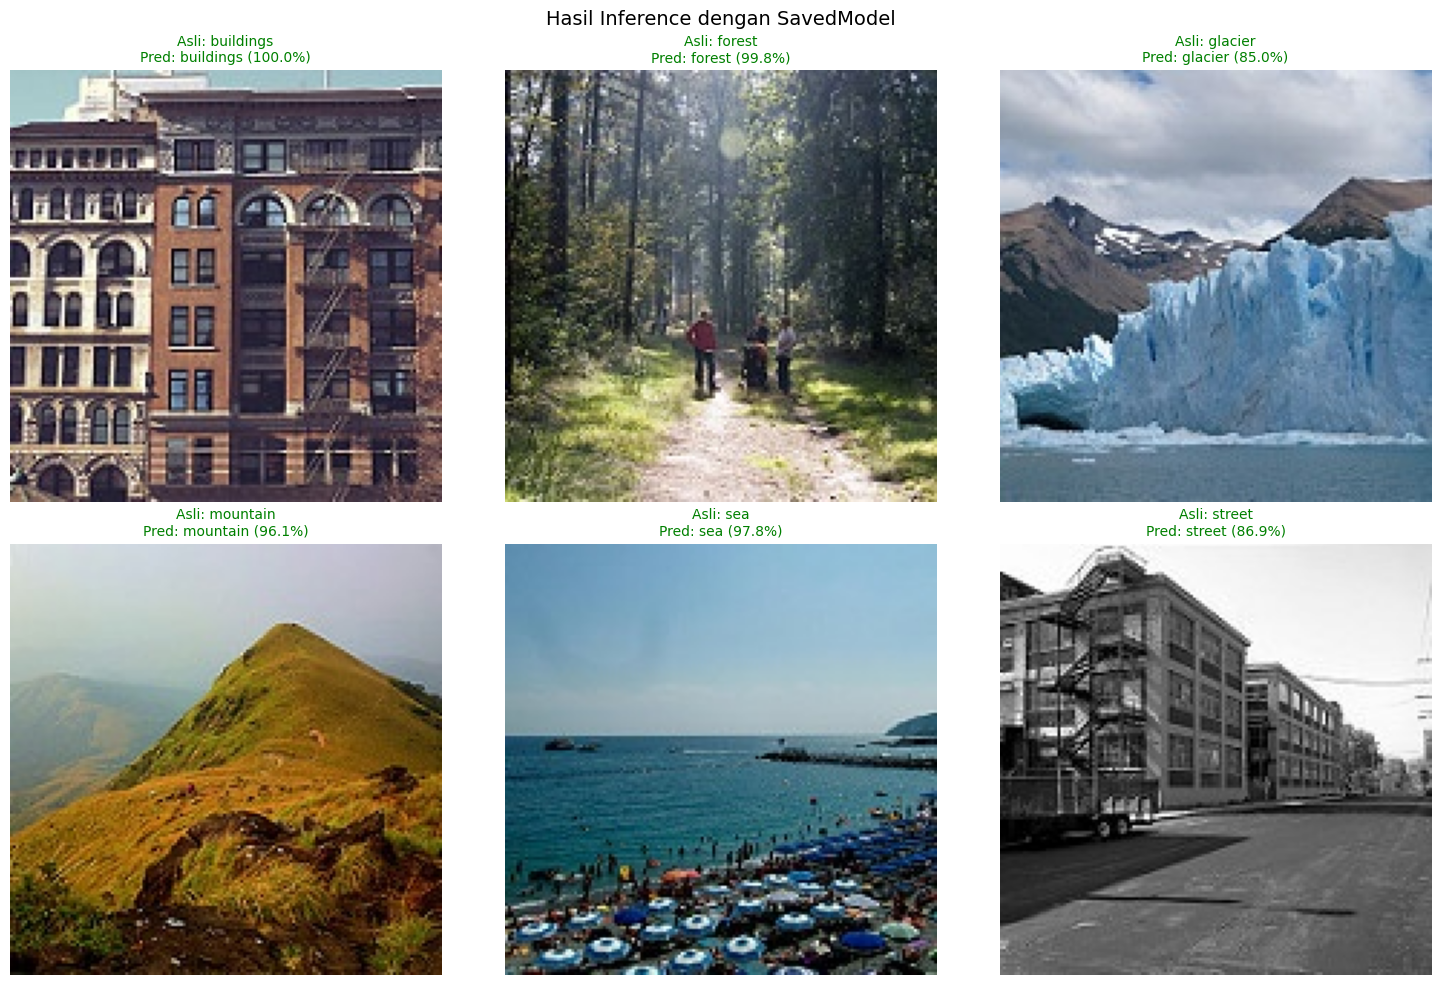

In [26]:
def preprocess_image(img_path, target_size=(224, 224)):
    """Load dan preprocessing satu gambar."""
    img = Image.open(img_path).convert('RGB')
    img = img.resize(target_size)
    img_array = np.array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

def predict_image(model, img_path, class_names):
    """Prediksi kelas dari satu gambar."""
    img_array = preprocess_image(img_path)
    predictions = model.predict(img_array, verbose=0)
    pred_idx   = np.argmax(predictions[0])
    confidence = predictions[0][pred_idx] * 100
    return class_names[pred_idx], confidence, predictions[0]

# Ambil beberapa gambar sampel dari test set
sample_images = []
sample_labels = []

for cls in CLASSES:
    cls_path = os.path.join(TEST_SPLIT, cls)
    files    = os.listdir(cls_path)
    if files:
        img_path = os.path.join(cls_path, random.choice(files))
        sample_images.append(img_path)
        sample_labels.append(cls)

# Inference dan visualisasi
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Hasil Inference dengan SavedModel', fontsize=14)

print('=== Hasil Prediksi (SavedModel) ===')
print(f'{"No":<4} {"Label Asli":<12} {"Prediksi":<12} {"Confidence":>12} {"Status"}')
print('-' * 55)

for idx, (img_path, true_label) in enumerate(zip(sample_images, sample_labels)):
    pred_label, confidence, probs = predict_image(best_model, img_path, CLASSES)
    status = 'Benar' if pred_label == true_label else 'Salah'
    print(f'{idx+1:<4} {true_label:<12} {pred_label:<12} {confidence:>10.2f}% {status}')

    # Tampilkan gambar
    img = mpimg.imread(img_path)
    ax  = axes[idx // 3][idx % 3]
    ax.imshow(img)
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'Asli: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
                 color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('inference_results.png', dpi=100, bbox_inches='tight')
plt.show()

### Inference dengan TF-Lite

In [27]:
# Load TF-Lite interpreter
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('TF-Lite Model Info:')
print(f'  Input shape : {input_details[0]["shape"]}')
print(f'  Input dtype : {input_details[0]["dtype"]}')
print(f'  Output shape: {output_details[0]["shape"]}')

def predict_tflite(interpreter, img_path, class_names):
    """Prediksi menggunakan TF-Lite interpreter."""
    img_array = preprocess_image(img_path).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    pred_idx   = np.argmax(output[0])
    confidence = output[0][pred_idx] * 100
    return class_names[pred_idx], confidence

print('\n=== Hasil Prediksi (TF-Lite) ===')
print(f'{"No":<4} {"Label Asli":<12} {"Prediksi":<12} {"Confidence":>12} {"Status"}')
print('-' * 55)

correct = 0
for idx, (img_path, true_label) in enumerate(zip(sample_images, sample_labels)):
    pred_label, confidence = predict_tflite(interpreter, img_path, CLASSES)
    status = 'Benar' if pred_label == true_label else 'Salah'
    if pred_label == true_label:
        correct += 1
    print(f'{idx+1:<4} {true_label:<12} {pred_label:<12} {confidence:>10.2f}% {status}')

print(f'\nAkurasi pada sampel: {correct}/{len(sample_images)} ({correct/len(sample_images)*100:.1f}%)')

TF-Lite Model Info:
  Input shape : [  1 224 224   3]
  Input dtype : <class 'numpy.float32'>
  Output shape: [1 6]

=== Hasil Prediksi (TF-Lite) ===
No   Label Asli   Prediksi       Confidence Status
-------------------------------------------------------
1    buildings    buildings        100.00% Benar
2    forest       forest            99.82% Benar
3    glacier      glacier           75.42% Benar
4    mountain     mountain          69.77% Benar
5    sea          sea               99.32% Benar
6    street       street            60.21% Benar

Akurasi pada sampel: 6/6 (100.0%)


## Ringkasan Akhir

In [28]:
print('=' * 60)
print('         RINGKASAN PROYEK KLASIFIKASI GAMBAR')
print('=' * 60)
print(f'Dataset     : Intel Image Classification')
print(f'Kelas       : {CLASSES}')
print(f'Jumlah Kelas: {len(CLASSES)}')
print(f'Total Data  : {total_train + total_val + total_test} gambar')
print(f'  - Train   : {total_train} ({total_train/(total_train+total_val+total_test)*100:.0f}%)')
print(f'  - Val     : {total_val} ({total_val/(total_train+total_val+total_test)*100:.0f}%)')
print(f'  - Test    : {total_test} ({total_test/(total_train+total_val+total_test)*100:.0f}%)')
print()
print(f'Akurasi Training (akhir) : {acc[-1]*100:.2f}%')
print(f'Akurasi Validasi (akhir) : {val_acc[-1]*100:.2f}%')
print(f'Akurasi Test             : {test_acc*100:.2f}%')
print()

         RINGKASAN PROYEK KLASIFIKASI GAMBAR
Dataset     : Intel Image Classification
Kelas       : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Jumlah Kelas: 6
Total Data  : 14034 gambar
  - Train   : 9820 (70%)
  - Val     : 2804 (20%)
  - Test    : 1410 (10%)

Akurasi Training (akhir) : 92.29%
Akurasi Validasi (akhir) : 91.69%
Akurasi Test             : 91.28%

